https://github.com/FabricioArendTorres/FlowConductor/tree/main

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt

import torch

from msi.flow_conductor import architecture
from msi.flow_conductor.likelihood_flow import LikelihoodFlow
from msi.utils import preprocessing
from msfm.utils import prior, parameters, files, logger

24-02-07 06:11:36   imports.py INF   Setting up healpy to run on 256 CPUs 
24-02-07 06:11:37   imports.py INF   Setting up healpy to run on 256 CPUs 


# load network predictions

### v4

In [3]:
# # combined probes
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

# # all parameters
# model_dir = "2023-08-31_03-29-47_resnet_vanilla"

# n_steps = 20000
# params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### v6

#### lensing only

In [4]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing_only"
base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing"

# delta loss
# model_dir = "delta/2024-01-12_19-35-59_resnet_vanilla"
model_dir = "delta/2024-02-06_11-02-57_resnet_vanilla"

# likelihood loss
# model_dir = "likelihood/2024-01-22_05-29-26_resnet_vanilla"

n_steps = 15000
params = ["Om", "s8", "w0", "Aia", "n_Aia"]

#### clustering only

#### combined probes

In [5]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v6/combined"

# # delta loss
# # model_dir = "delta/2024-02-02_00-28-48_resnet_vanilla"


# # likelihood loss
# # model_dir = "likelihood/2024-01-30_07-41-40_resnet_vanilla"
# model_dir = "likelihood/2024-02-01_09-02-59_resnet_vanilla"

# n_steps = 100000
# # params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### general

In [6]:
# dataset
fidu_preds, grid_preds, grid_cosmos, file_dict = preprocessing.get_reshaped_network_preds(
    base_dir, model_dir, n_steps, n_params=len(params)
)

# output directory and file names
out_dir = os.path.join(base_dir, model_dir)
label = f"{n_steps}_steps"

24-02-07 06:11:38 input_output INF   Array shapes: 
24-02-07 06:11:38 input_output INF   fiducial/vali/pred = (4, 5) 
24-02-07 06:11:38 input_output INF   fiducial/vali/i_example = (4,) 
24-02-07 06:11:38 input_output INF   fiducial/vali/i_noise = (4,) 
24-02-07 06:11:38 input_output INF   grid/pred          = (2500, 48, 5) 
24-02-07 06:11:38 input_output INF   grid/cosmo         = (2500, 5) 
24-02-07 06:11:38 input_output INF   grid/i_example     = (2500, 48) 
24-02-07 06:11:38 input_output INF   grid/i_noise       = (2500, 48) 
24-02-07 06:11:38 input_output INF   grid/i_sobol       = (2500,) 


24-02-07 06:11:38 preprocessin INF   Shapes after concatenation and selection: 
24-02-07 06:11:38 preprocessin INF   fidu_preds  = (4, 5) 
24-02-07 06:11:38 preprocessin INF   grid_preds  = (120000, 5) 
24-02-07 06:11:38 preprocessin INF   grid_cosmos = (120000, 5) 


# likelihood Flow $p(x|\theta)$

### architecture

In [7]:
# input dimensions
x_dim = grid_preds.shape[-1]
theta_dim = grid_cosmos.shape[-1]

# shared hyperparameters
context_embedding_dim = 32

embedding_net = architecture.get_context_embedding_net(
    context_dim=theta_dim,
    context_embedding_dim=context_embedding_dim,
    hidden_dim=64,
    n_blocks=3,
    dropout_probability=0.0,
    use_batch_norm=False,
)    

base_dist = architecture.get_normal_dist(
    feature_dim=x_dim,
)

transform = architecture.get_sigmoids_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=8,
    hidden_dim=256,
    svd_kwargs={},
    sigmoids_kwargs={
        "n_sigmoids": 16,
        "num_blocks": 3,
        "dropout_probability": 0.0,
    }
)

# transform = architecture.get_lipschitz_transform(
#     feature_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=5,
#     hidden_dim=128,
# )

flow = LikelihoodFlow(
    params, 
    conf, 
    embedding_net=embedding_net,
    base_dist=base_dist,
    transform=transform,
    out_dir=out_dir, 
    label=label,
    load_existing=True,
)

24-02-07 06:11:38 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v6/lensing/delta/2024-02-06_11-02-57_resnet_vanilla/15000_steps/likelihood_flow 
24-02-07 06:11:38 likelihood_f INF   Initialized the normalizing flow 
24-02-07 06:11:39 likelihood_f INF   Running on device cuda with default float torch.float32 
24-02-07 06:11:39 likelihood_f WAR   Could not load the model from /pscratch/sd/a/athomsen/run_files/v6/lensing/delta/2024-02-06_11-02-57_resnet_vanilla/15000_steps/likelihood_flow/likelihood_flow.pt 


### training

24-02-07 06:26:32 likelihood_f INF   Using a cosine annealing scheduler 
24-02-07 06:26:32 likelihood_f INF   Using early stopping with patience 10 and min delta 0.0 
 57%|███████████████▉            |   | 57/100 [08:14<06:35,  9.20s/it]        lr: 3.97E-04, train: -12.25, vali: -12.56: 24-02-07 06:34:56   pytorch.py INF   <All keys matched successfully> 
24-02-07 06:34:56   pytorch.py INF   Restored the weights from the best epoch (vali_loss = -13.02) 
24-02-07 06:34:56 likelihood_f INF   Stopping early after 57 epochs 
 57%|███████████████▉            |   | 57/100 [08:23<06:19,  8.84s/it]        lr: 3.97E-04, train: -12.25, vali: -12.56: 
24-02-07 06:34:56 likelihood_f INF   Saved the model to /pscratch/sd/a/athomsen/run_files/v6/lensing/delta/2024-02-06_11-02-57_resnet_vanilla/15000_steps/likelihood_flow/likelihood_flow.pt 


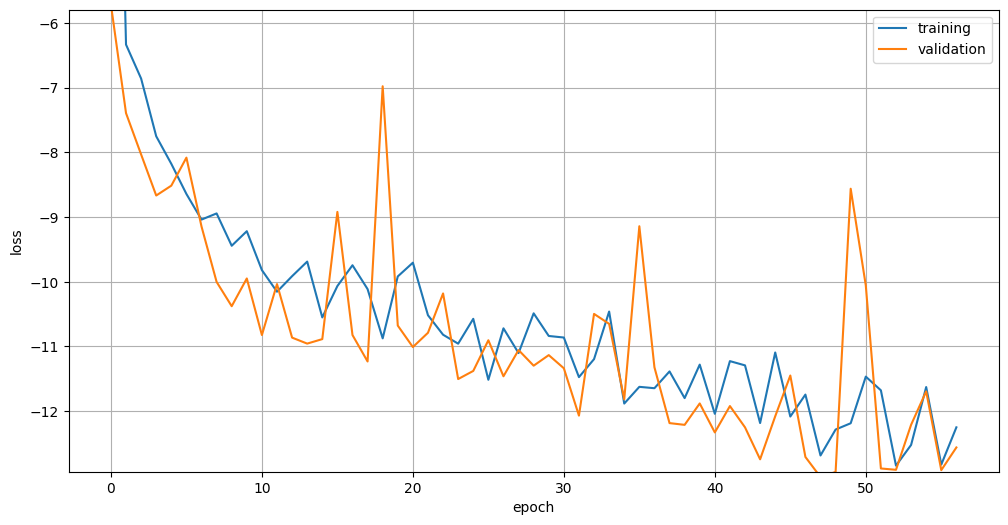

In [15]:
flow.fit(
    x=grid_preds,
    theta=grid_cosmos,
    n_epochs=100,
    # dataset
    batch_size=1000,
    vali_split=0.1,
    # optimizer
    learning_rate=1e-3,
    weight_decay=0.0,
    clip_by_global_norm=1.0,
    # scheduler
    scheduler_type="cosine",
    # early stopping
    n_patience_epochs=10,
    min_delta=0.0,
    save_model=True,
)

24-02-07 06:36:23 likelihood_f INF   Not using a learning rate scheduler 
24-02-07 06:36:23 likelihood_f INF   Using early stopping with patience 10 and min delta 0.0 
 41%|███████████▍                |   | 41/100 [05:33<07:45,  7.89s/it]        lr: 1.00E-05, train: -14.17, vali: -14.15: 24-02-07 06:42:05   pytorch.py INF   <All keys matched successfully> 
24-02-07 06:42:05   pytorch.py INF   Restored the weights from the best epoch (vali_loss = -14.15) 
24-02-07 06:42:05 likelihood_f INF   Stopping early after 41 epochs 
 41%|███████████▍                |   | 41/100 [05:42<08:12,  8.35s/it]        lr: 1.00E-05, train: -14.17, vali: -14.15: 
24-02-07 06:42:05 likelihood_f INF   Saved the model to /pscratch/sd/a/athomsen/run_files/v6/lensing/delta/2024-02-06_11-02-57_resnet_vanilla/15000_steps/likelihood_flow/likelihood_flow.pt 


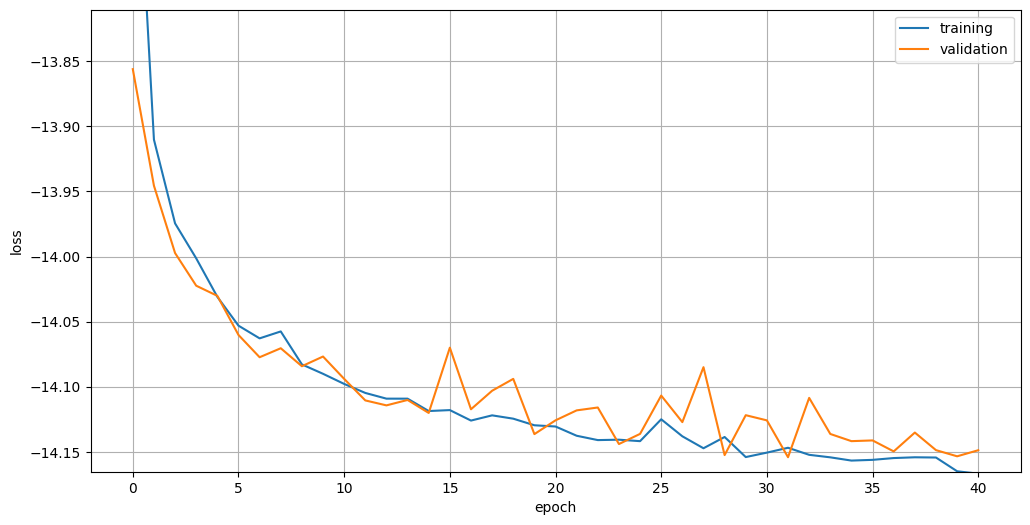

In [17]:
flow.fit(
    x=grid_preds,
    theta=grid_cosmos,
    n_epochs=100,
    # dataset
    batch_size=1000,
    vali_split=0.1,
    # optimizer
    learning_rate=1e-5,
    weight_decay=0.0,
    clip_by_global_norm=1.0,
    # scheduler
    # scheduler_type="cosine",
    # scheduler_kwargs={"eta_min": 1e-7},
    # early stopping
    n_patience_epochs=10,
    min_delta=0.0,
    save_model=True,
)

### convergence tests

24-02-07 06:42:28 likelihood_b INF   Drawing samples from the likelihood 
24-02-07 06:42:40 likelihood_b INF   Done drawing samples after 0:00:12.42 
100%|████████████████████████████|   | 2500/2500 [00:00<00:00, 10264.64it/s]  EECP: looping through cosmos
24-02-07 06:42:50 diagnostics. INF   TARP random reference points: Using the default 
100%|████████████████████████████|   | 48/48 [00:00<00:00, 100.16it/s]        TARP: looping through examples


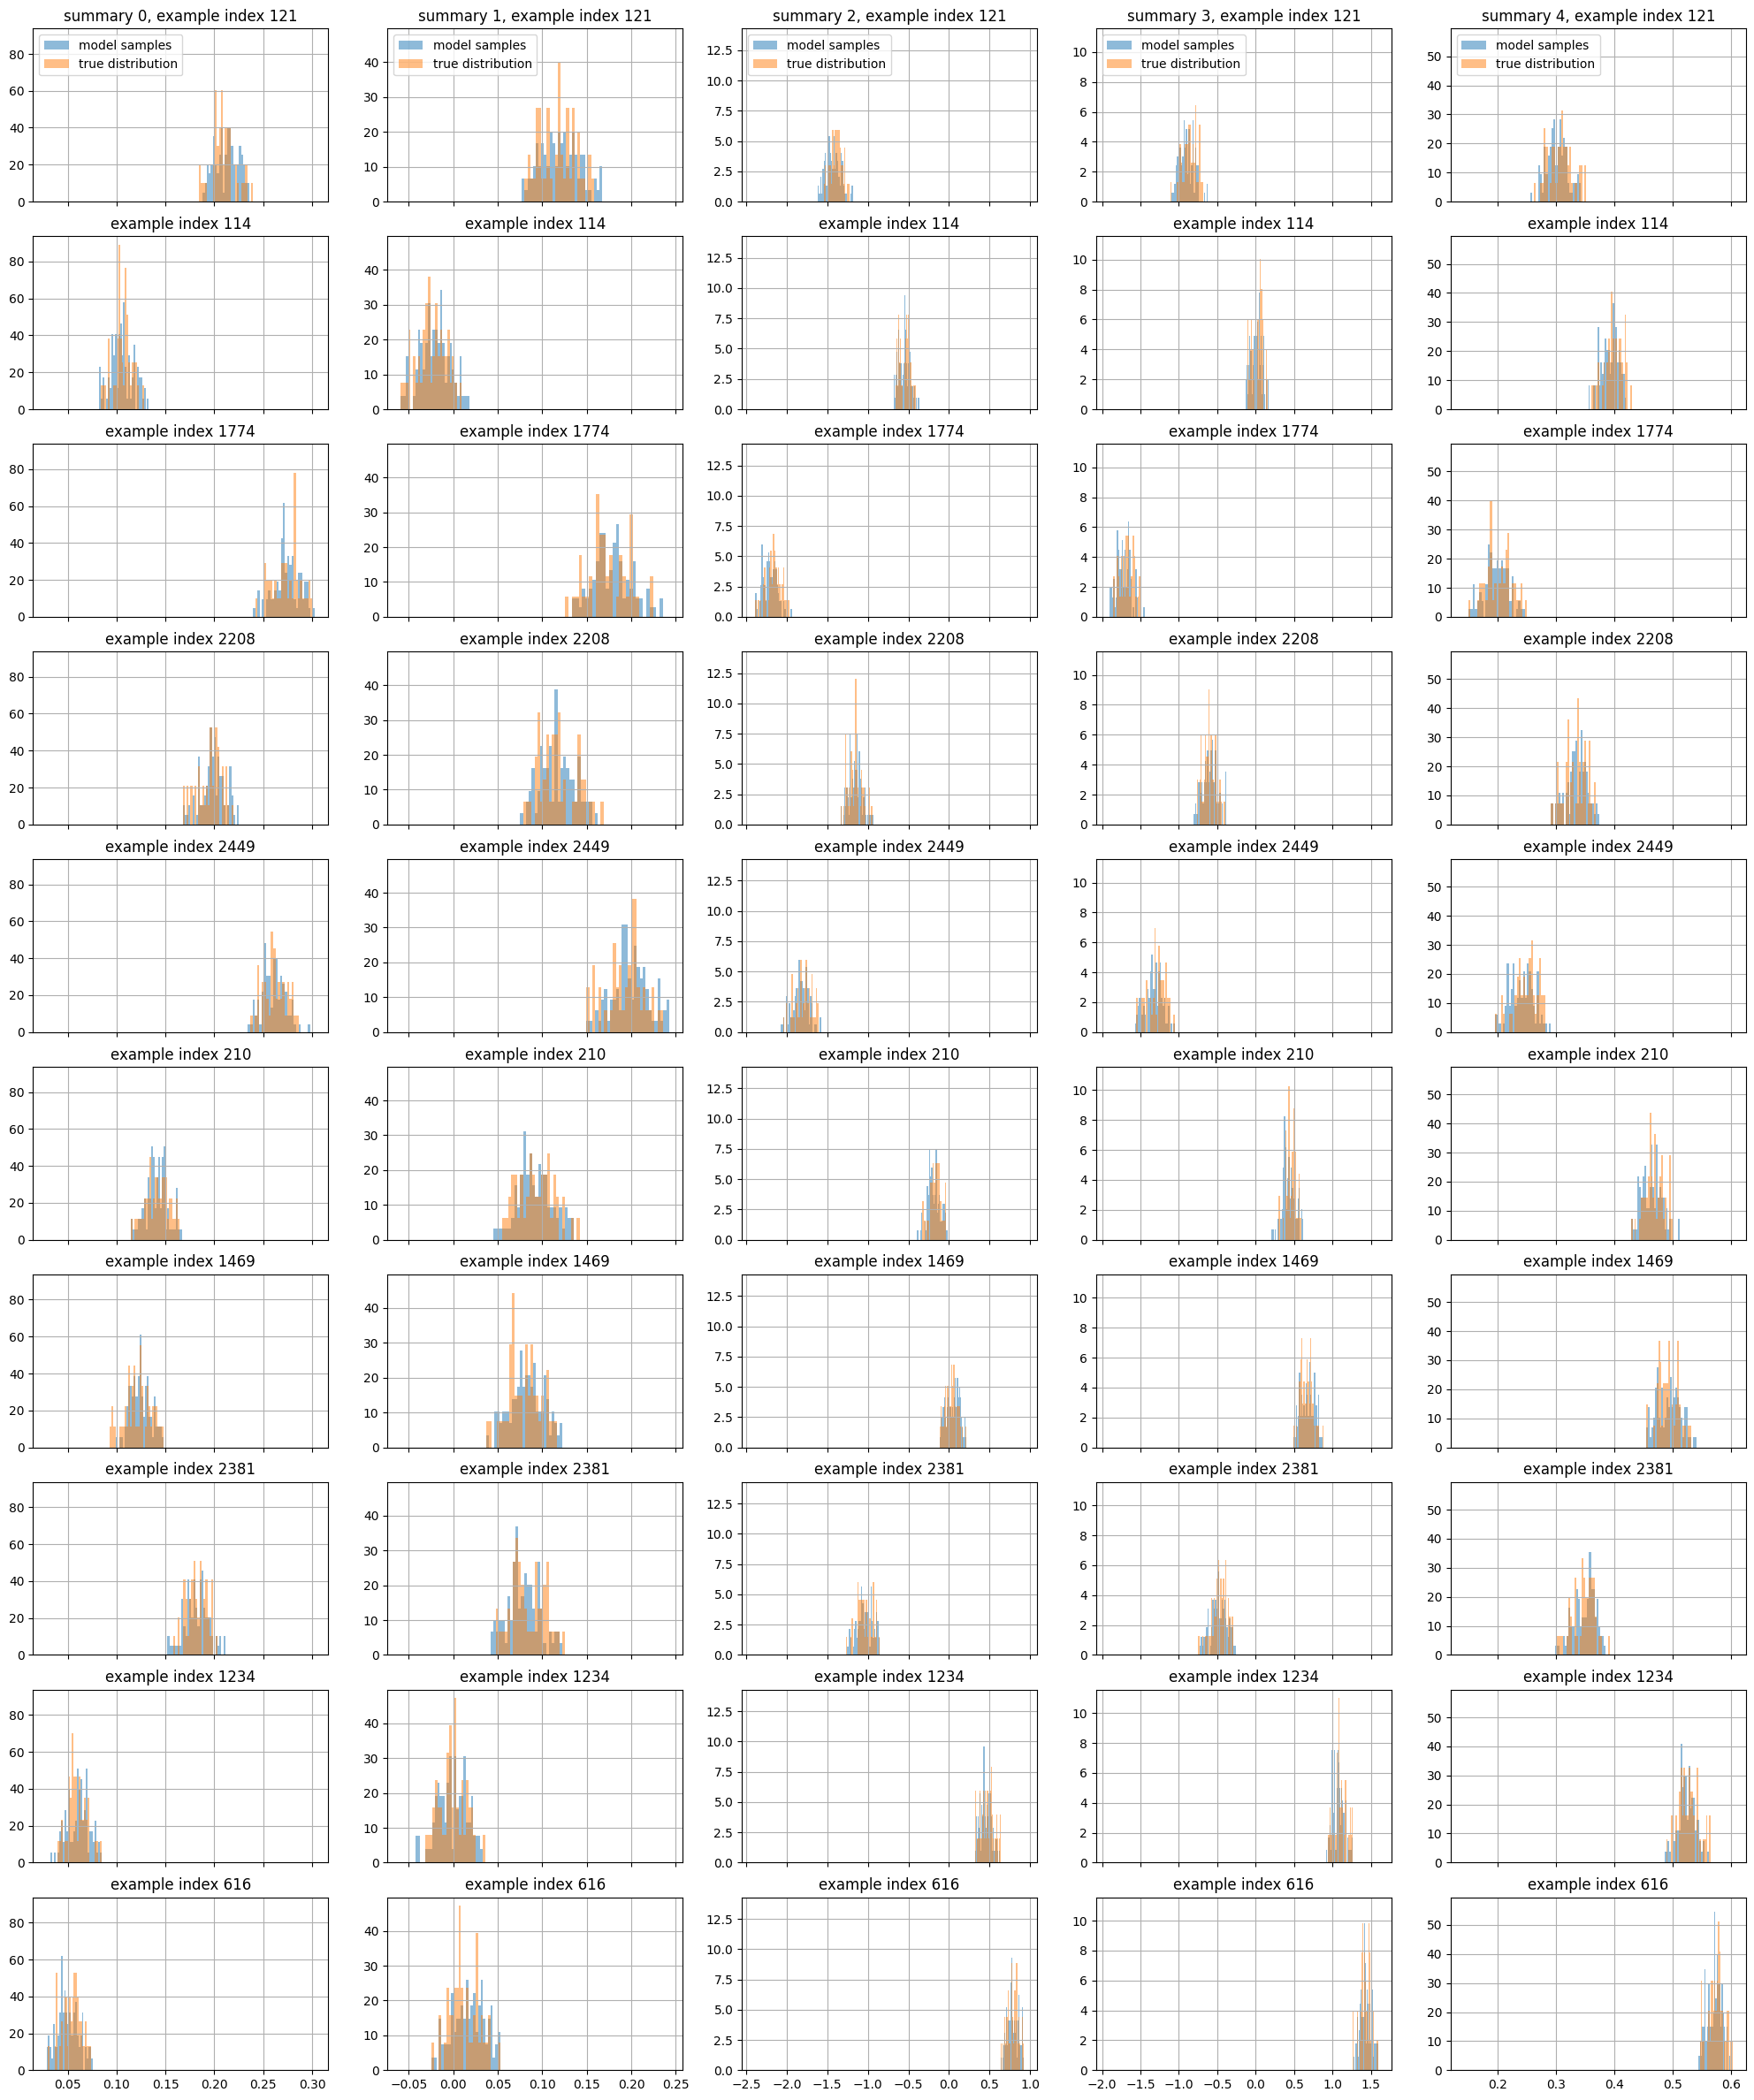

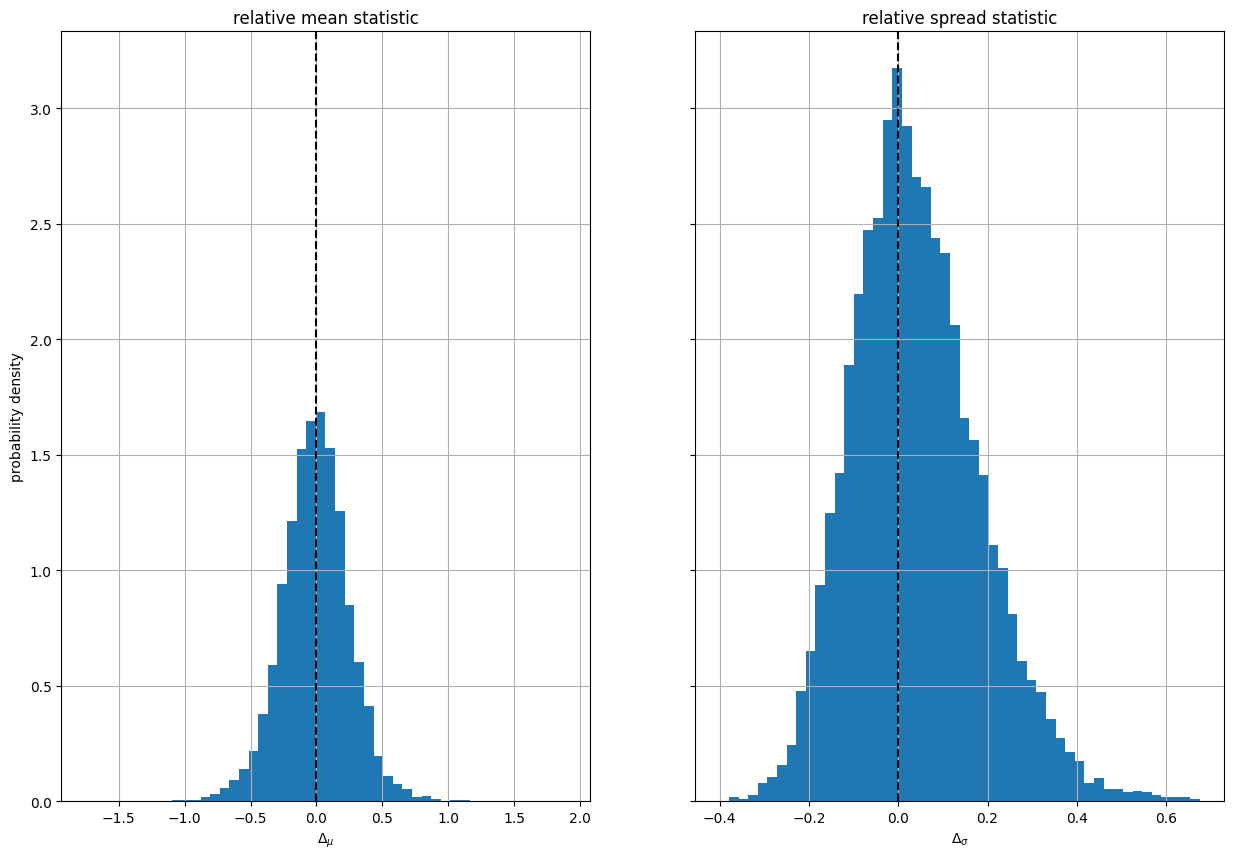

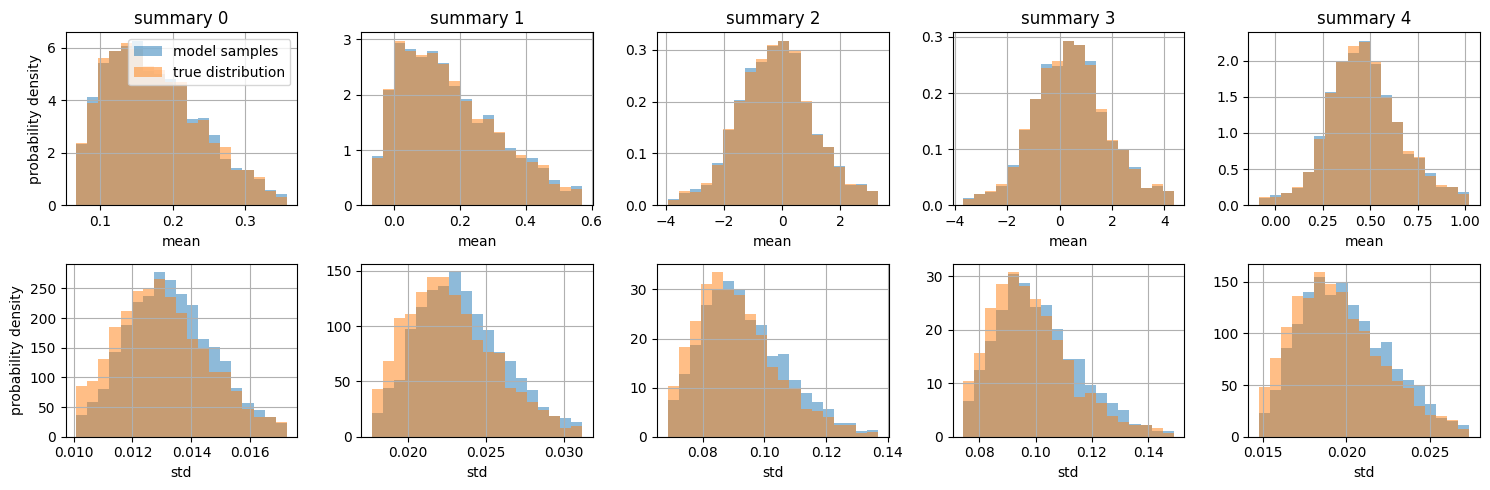

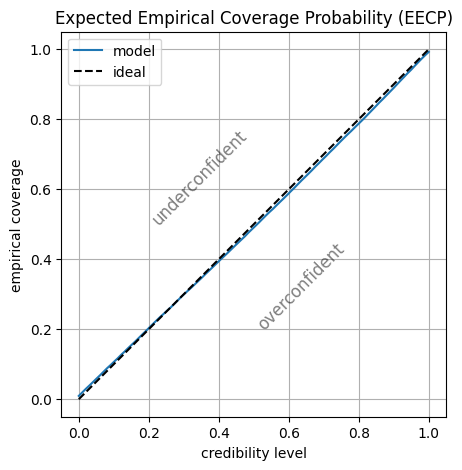

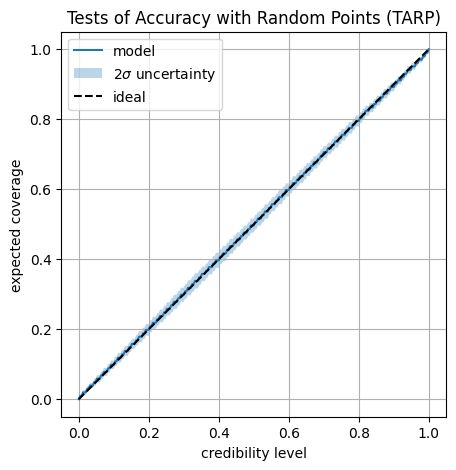

In [18]:
grid_preds_sample = flow.plot_diagnostics(
    # these must be the raw arrays where the cosmo and example axis are still separate
    grid_preds_true=file_dict["grid/pred"][...,:len(params)], 
    grid_cosmos=file_dict["grid/cosmo"],
    n_samples=100,
    # do_hist=True,
    do_dlss=True,
    do_eecp=True,
    do_tarp=True,
)

### observation

In [19]:
i_obs = 0
# i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))

print(f"Using the example index {i_obs}")
obs_pred = fidu_preds[i_obs]

Using the example index 0


### MCMC

In [20]:
posterior_samples = flow.sample_posterior(
    obs_pred,
)

24-02-07 06:43:12      mcmc.py INF   Initial values in prior: True 
24-02-07 06:43:12      mcmc.py INF   Starting the burn in MCMC chain (100 steps) 
24-02-07 06:43:19      mcmc.py INF   Starting the main MCMC chain (500 steps) 


100%|██████████| 500/500 [00:33<00:00, 14.72it/s]

24-02-07 06:43:53      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v6/lensing/delta/2024-02-06_11-02-57_resnet_vanilla/15000_steps/likelihood_flow/chain.npy 


### plotting

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

24-02-07 06:43:56  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v6/lensing/delta/2024-02-06_11-02-57_resnet_vanilla/15000_steps/likelihood_flow/contours.png 


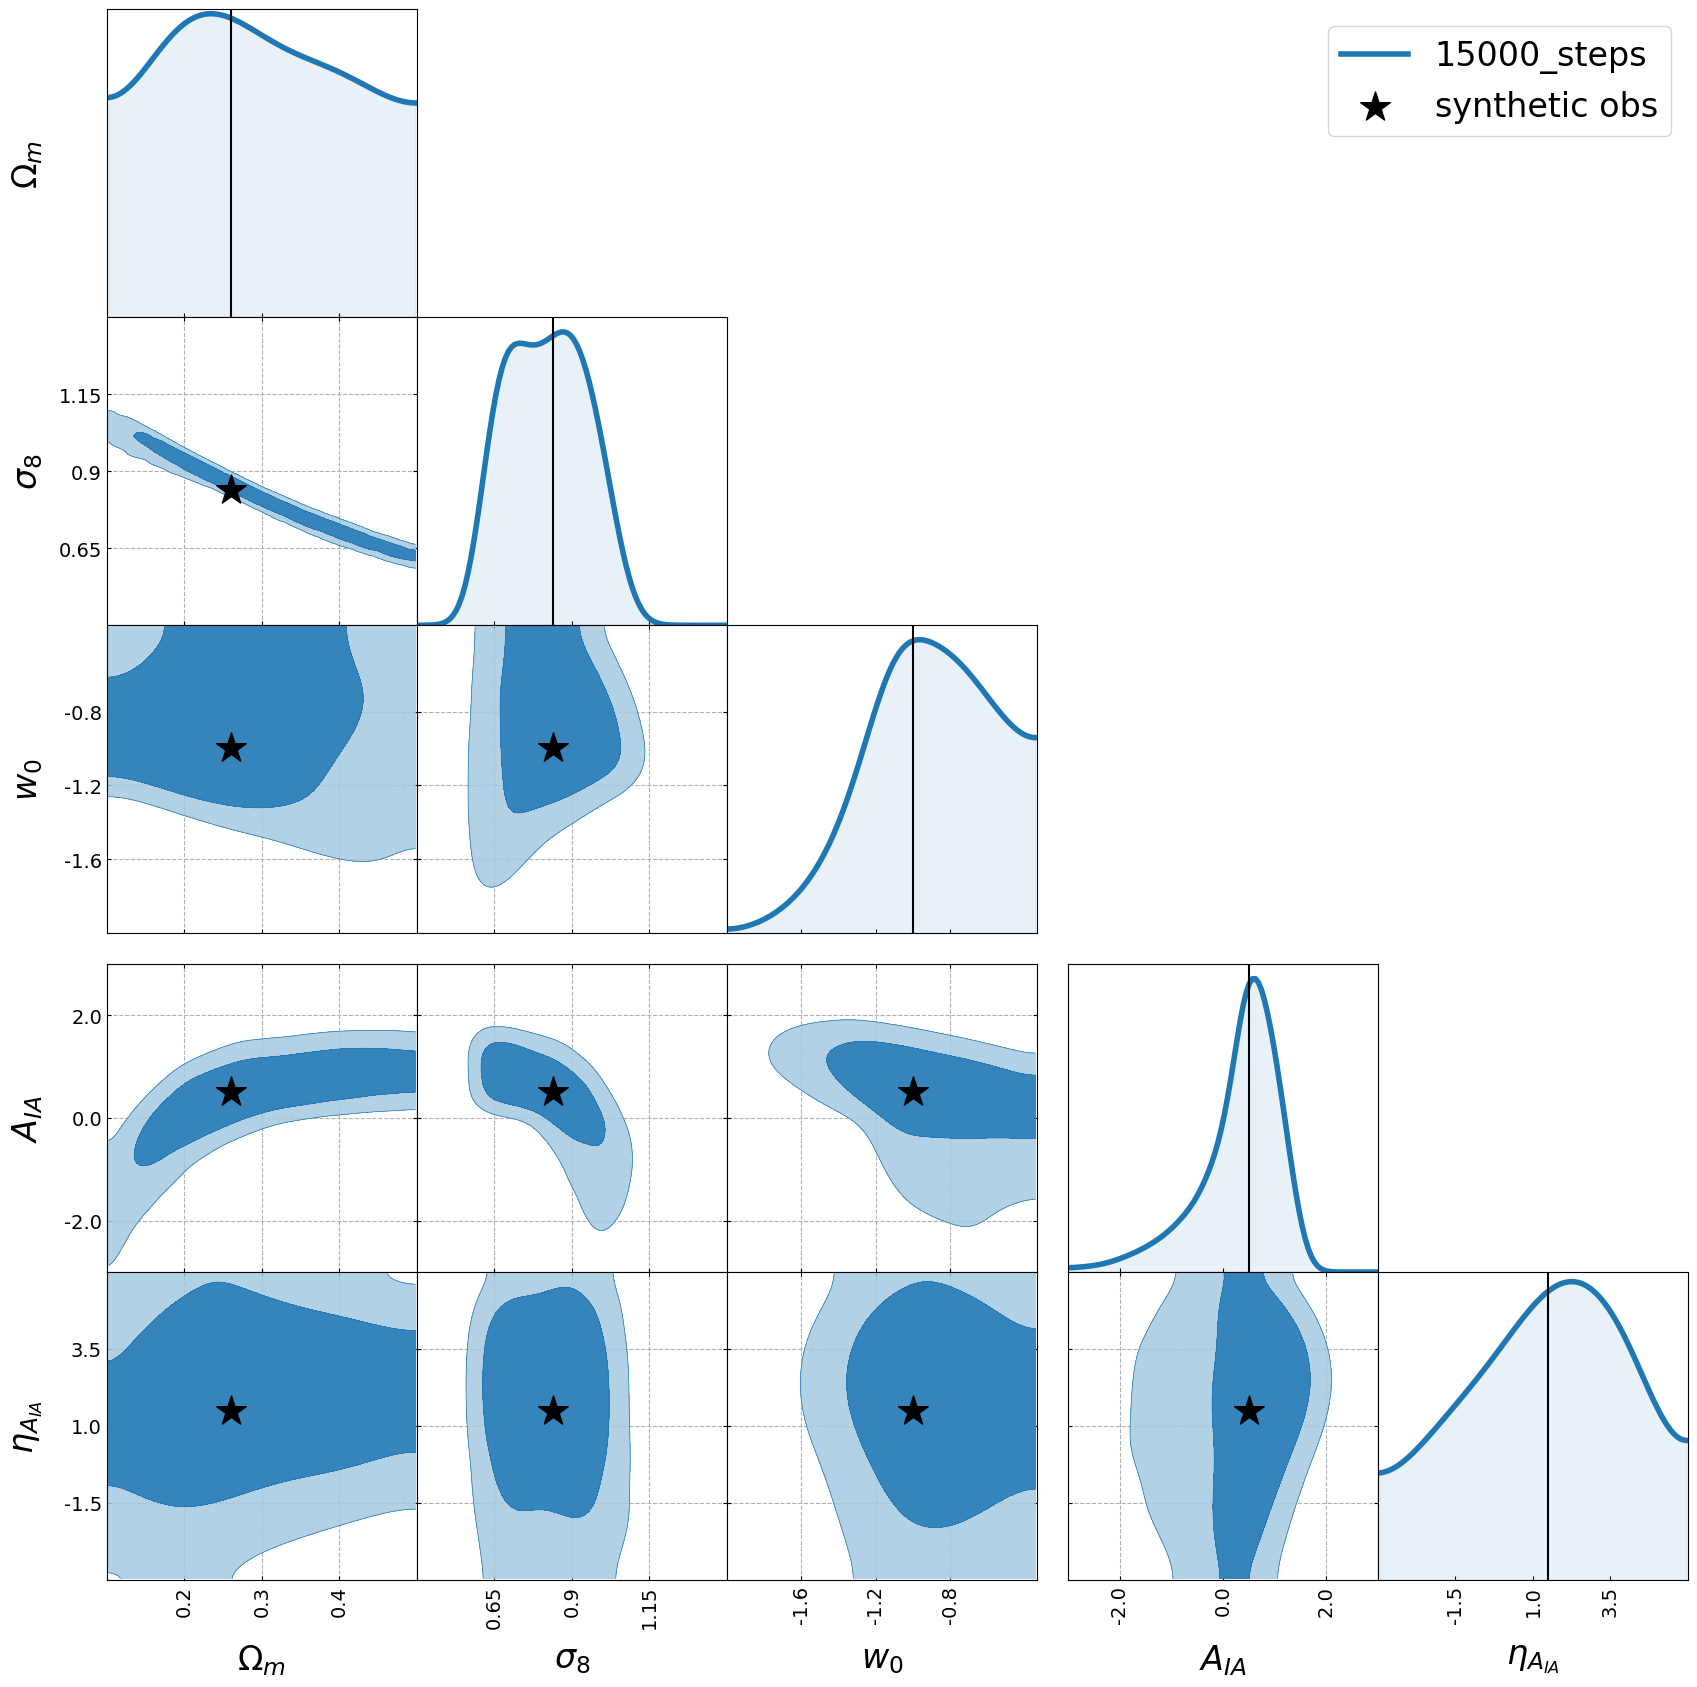

In [21]:
flow.plot_contours(
    posterior_samples,
)